# Uber Surge Pricing Analysis – Annotated for Beginners

## What is this notebook about?

We are trying to answer a simple question:
**What causes someone to wait longer for an Uber pick-up?**

We test several statistical models (called **OLS regression**) that each
try to predict `pick_up_time` (how many minutes until your driver arrives)
using different combinations of:

| Variable | What it means |
|---|---|
| `number_of_drivers` | How many drivers are currently available in the area |
| `surge_price` | The price multiplier Uber charges when demand is high (e.g. 1.8× means 80% more than normal) |
| `region` | Whether the pick-up is in the city centre (`core`) or suburbs (`suburb`) |

---

## Key vocabulary for beginners

- **OLS (Ordinary Least Squares)** – The most common type of linear regression. It finds the best-fit straight line through your data by minimising the sum of squared errors.
- **R² (R-squared)** – How much of the variation in `pick_up_time` the model explains. Ranges from 0 (explains nothing) to 1 (perfect fit).
- **Adjusted R²** – Like R², but penalises you for adding extra predictors that don't genuinely help. Use this when comparing models with different numbers of variables.
- **AIC** – Another way to compare models; lower is better.
- **p-value** – Tells you whether a predictor is statistically significant. Convention: p < 0.05 = significant.
- **Residuals** – The difference between what the model predicted and what actually happened.
- **Multicollinearity** – When two predictors are so strongly correlated that the model can't separate their individual effects.
- **VIF** – A score measuring multicollinearity. VIF > 10 (some say > 5) is a warning sign.

---

## Models we build

| Model | Formula | Purpose |
|---|---|---|
| M0 | Intercept only | Baseline – just predict the mean every time |
| M1 | ~ number_of_drivers | Does driver supply alone predict wait time? |
| M2 | ~ number_of_drivers + surge_price | Does adding surge price help? (Spoiler: multicollinearity) |
| M3 | ~ surge_price only | After discovering M2's problem, surge price alone |
| M4 | ~ number_of_drivers + region | Does neighbourhood matter on top of driver supply? |


# Uber Surge Pricing Analysis

This notebook models **pick-up time** as a function of supply and demand variables using OLS regression.

| Model | Formula |
|---|---|
| M0 | Intercept only (baseline) |
| M1 | ~ number_of_drivers |
| M2 | ~ number_of_drivers + surge_price |
| M3 | ~ surge_price only (after discovering multicollinearity) |
| M4 | ~ number_of_drivers + region |

## 1. Import Libraries

## Section 1 – Import Libraries

Before doing any analysis we load the Python packages we'll need.
Think of packages as **toolboxes** – each one contains ready-made tools
so we don't have to write everything from scratch.

| Package | What we use it for |
|---|---|
| `pandas` (pd) | Working with tables of data (DataFrames) |
| `numpy` (np) | Maths and array operations |
| `seaborn` (sns) | Beautiful statistical charts |
| `matplotlib.pyplot` (plt) | Lower-level plotting (seaborn sits on top) |
| `scipy.stats` | Statistical functions – used for the Q-Q plot |
| `statsmodels.formula.api` (smf) | OLS regression with R-style formulas |
| `summary_col` | Print a side-by-side comparison table of models |
| `variance_inflation_factor` | Check for multicollinearity (VIF) |


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # suppress harmless deprecation warnings

from scipy import stats                                    # used for the Q-Q probability plot
import statsmodels.formula.api as smf                    # OLS regression with R-style formulas
from statsmodels.iolib.summary2 import summary_col        # side-by-side model comparison table
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity check


## 2. Helper Function: `fit_and_plot`

Fits an OLS model and produces a 3-panel diagnostic plot:
- **Top**: actual vs predicted (scatter for continuous x, stripplot + mean lines for categorical x)
- **Bottom-left**: residuals vs fitted
- **Bottom-right**: Q-Q plot of residuals

## Section 2 – Helper Function: `fit_and_plot`

Instead of repeating the same plotting code for every model we create,
we write it **once** as a function and call it each time.

The function does three things:
1. **Fits** an OLS model using the formula and data you give it.
2. **Prints** the full regression summary table.
3. **Draws** a 3-panel diagnostic chart:
   - **Top panel** – Actual vs Predicted values so you can see how well
     the model tracks the real data. For a *categorical* predictor (like
     `region`) it draws a strip-plot with mean lines; for a *continuous*
     predictor it draws a scatter plot.
   - **Bottom-left** – Residuals vs Fitted values. A good model shows
     points scattered randomly around the horizontal zero line; any
     pattern here hints at a violated assumption.
   - **Bottom-right** – Q-Q (Quantile-Quantile) plot of the residuals.
     Points close to the diagonal line mean the residuals are
     approximately **normally distributed** – an OLS requirement.

The function also returns the fitted model object so you can inspect it
further (e.g. extract coefficients or predictions).


In [1]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()

    # ── Compact summary ───────────────────────────────────────────────────────
    rse = np.sqrt(model.mse_resid)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  R²: {model.rsquared:.4f}    Adj R²: {model.rsquared_adj:.4f}    Residual SE: {rse:.4f}")
    print(f"  Observations: {int(model.nobs)}    df residual: {int(model.df_resid)}")
    print(f"{'-'*55}")
    print(f"  {'Coefficient':<20} {'Estimate':>10} {'Std Err':>10} {'t':>8} {'P>|t|':>8}")
    print(f"{'-'*55}")
    for name, coef, se, tval, pval in zip(
        model.params.index,
        model.params,
        model.bse,
        model.tvalues,
        model.pvalues
    ):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.1 else ""
        print(f"  {name:<20} {coef:>10.4f} {se:>10.4f} {tval:>8.3f} {pval:>8.4f} {sig}")
    print(f"{'='*55}\n")

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    residuals = model.resid
    is_cat    = data[x_var].dtype == object or str(data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # ── 1. Actual vs Predicted ────────────────────────────────────────────────
    if is_cat:
        sns.stripplot(x=data[x_var], y=data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(data[x_var], data[y_var],
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(data[x_var], model.fittedvalues,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted — x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # ── 2. Residuals vs Fitted ────────────────────────────────────────────────
    ax_res.scatter(model.fittedvalues, residuals,
                   alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # ── 3. Q-Q plot ───────────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # ── Suptitle with all three stats ─────────────────────────────────────────
    plt.suptitle(
        f'{model_name}  |  R² = {model.rsquared:.3f}  |  Adj R² = {model.rsquared_adj:.3f}  |  Residual SE = {rse:.3f}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    return model

## 3. Load & Inspect Data

## Section 3 – Load & Inspect the Data

We download the Uber surge dataset directly from GitHub using its raw URL.
After loading, we call `.info()` to quickly see:
- **how many rows** (observations) we have
- **what columns** exist and their **data types** (`float64`, `int64`, `str`)
- whether there are any **missing values** (Non-Null Count < total rows)

Our dataset has **15 rows** and **4 columns**:

| Column | Type | Description |
|---|---|---|
| `pick_up_time` | float64 | Minutes until the driver arrives *(outcome we want to predict)* |
| `number_of_drivers` | int64 | Drivers currently available in the zone |
| `surge_price` | float64 | Price multiplier (1.0 = no surge, 2.4 = 2.4× normal fare) |
| `region` | str | `'core'` (city centre) or `'suburb'` |


In [3]:
# Download the dataset directly from the course GitHub repository.
# pd.read_csv() can accept a URL just like a local file path.
uber_surge = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/uber_surge.csv")

# .shape returns (rows, columns) so we know the size of the dataset.
print(f"Shape: {uber_surge.shape}")

# .info() shows column names, non-null counts, and data types in one go.
uber_surge.info()


Shape: (15, 4)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pick_up_time       15 non-null     float64
 1   number_of_drivers  15 non-null     int64  
 2   surge_price        15 non-null     float64
 3   region             15 non-null     str    
dtypes: float64(2), int64(1), str(1)
memory usage: 612.0 bytes


### Summary Statistics

`.describe()` gives us the classic five-number summary for every numeric column:
count, mean, std (standard deviation), min, 25th percentile, median, 75th percentile, max.

We transpose (`.T`) so each variable is a *row* instead of a *column* – easier to read.
We round to 2 decimal places with `.round(2)`.

Key observations:
- Average pick-up time ≈ **7.9 minutes** (range 3–12 min).
- Driver count ranges from **0 to 18** — quite variable.
- Surge price ranges from **1.0× to 2.4×**.


In [18]:
# .describe() computes summary statistics for every numeric column.
# .T transposes so rows = variables (easier to read).
# .round(2) limits decimal places.
uber_surge.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
pick_up_time,15.0,7.87,2.84,3.0,5.9,8.0,10.3,12.0
number_of_drivers,15.0,9.13,5.49,0.0,5.5,9.0,13.0,18.0
surge_price,15.0,1.70,0.38,1.0,1.5,1.8,1.9,2.4


## 4. Correlation Heatmap

Check the strength and direction of linear relationships between numeric variables.
A very high correlation between two predictors (|r| > 0.8) is a warning sign for **multicollinearity**.

## Section 4 – Correlation Heatmap

Before building any model it's smart to look at **pairwise correlations** among
the numeric variables.

A correlation coefficient (*r*) ranges from **−1** (perfect negative relationship)
to **+1** (perfect positive relationship). Zero means no linear relationship.

We use a **heatmap** to show all correlations at once. The color scale goes:
- 🔵 Blue → strong negative correlation
- ⚪ White → near zero
- 🔴 Red → strong positive correlation

**What to watch for:** If two *predictors* are very highly correlated with each
other (|r| > 0.8), including both in the same model causes **multicollinearity**
— which we'll see blow up in Model 2.


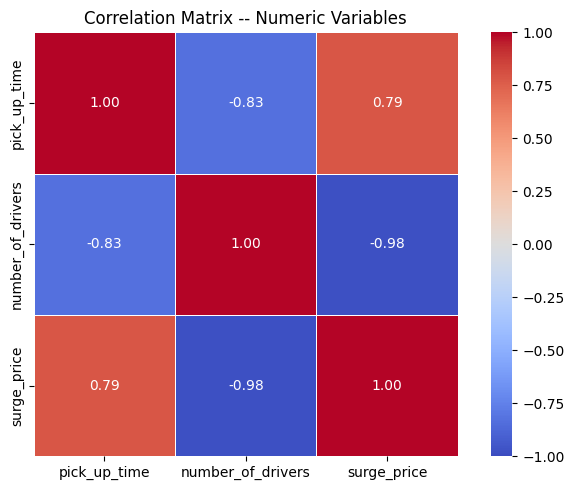

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

# .drop(columns=['region']) excludes the categorical column because
# standard Pearson correlation only works on numeric variables.
# .corr() computes the pairwise correlation matrix.
sns.heatmap(
    uber_surge.drop(columns=['region']).corr(),
    annot=True, fmt='.2f',          # show numbers inside each cell
    cmap='coolwarm', center=0,       # diverging palette: blue=negative, red=positive
    vmin=-1, vmax=1,                 # fix color scale to [-1, +1]
    square=True, linewidths=0.5,     # square cells, thin grid lines
    ax=ax
)

ax.set_title('Correlation Matrix -- Numeric Variables')
plt.tight_layout()
plt.show()


## 5. Model 0 — Intercept Only (Baseline)

Predicts every observation as the overall mean. R-squared = 0 by definition. Any useful predictor should beat this.

## Section 5 – Model 0: Intercept Only (Baseline)

The simplest possible model: **predict the same value for everyone** — the overall mean
of `pick_up_time` (≈ 7.87 minutes).

This is our **baseline**. Any useful predictor must beat this model.

- **R² = 0.000** — by definition, because this model explains none of the variation.
- **Intercept = 7.867** — this is just the sample mean of `pick_up_time`.

The formula `pick_up_time ~ 1` means "fit only the intercept, no predictors".


In [4]:
# 'pick_up_time ~ 1' means: predict pick_up_time using only an intercept.
# This produces a flat line at the mean — our do-nothing baseline.
model0 = smf.ols('pick_up_time ~ 1', data=uber_surge).fit()
print(model0.summary())


                            OLS Regression Results                            
Dep. Variable:           pick_up_time   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                nan
Time:                        20:03:36   Log-Likelihood:                -36.419
No. Observations:                  15   AIC:                             74.84
Df Residuals:                      14   BIC:                             75.55
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.8667      0.733     10.731      0.0

## 6. Model 1 — Pick-Up Time ~ Number of Drivers

We expect a **negative** coefficient: more drivers available -> shorter wait.

## Section 6 – Model 1: Pick-Up Time ~ Number of Drivers

Our first real model. Hypothesis: **more drivers → shorter wait**.

We expect a **negative coefficient** on `number_of_drivers` — as supply goes up,
wait time goes down.

From the output:
- **Intercept ≈ 11.81** — expected wait (in minutes) when there are zero drivers.
- **Coefficient ≈ −0.43** — every additional driver reduces the wait by ~0.43 minutes.
- **R² ≈ 0.697** — driver count explains ~70% of the variation in wait time. Not bad!
- **p-value < 0.001** — the relationship is highly statistically significant.



  M1: Pick-Up Time ~ Drivers
  R²: 0.6970    Adj R²: 0.6737    Residual SE: 1.6219
  Observations: 15    df residual: 13
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               11.8111     0.8341   14.161   0.0000 ***
  number_of_drivers       -0.4319     0.0790   -5.468   0.0001 ***



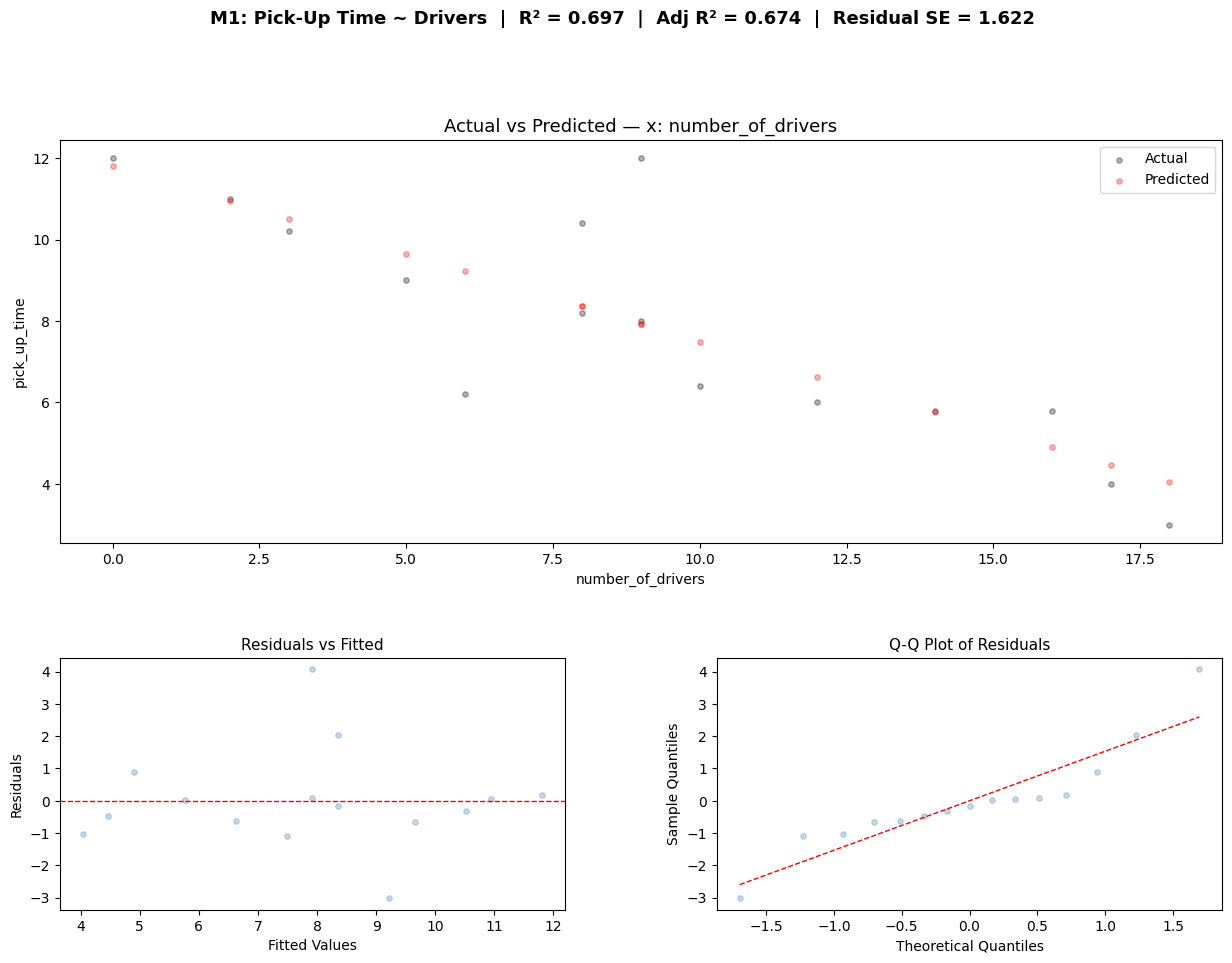

In [5]:
# Model 1: predict pick_up_time from number_of_drivers alone.
# fit_and_plot() fits the model, prints the summary, and draws the 3-panel chart.
model1 = fit_and_plot(
    formula='pick_up_time ~ number_of_drivers',
    data=uber_surge,
    model_name='M1: Pick-Up Time ~ Drivers',
    x_var='number_of_drivers'  # tells the function which variable to plot on the X-axis
)


## 7. Augment Data with Predictions

Attach fitted values, residuals, and prediction intervals back onto the original DataFrame -- equivalent to `broom::augment()` in R.

## Section 7 – Augment the Data with Predictions

We attach the model's predictions back onto the original DataFrame — similar to
the `broom::augment()` function in R.

`.get_prediction()` returns predicted values **plus uncertainty intervals**:
- `mean` – the model's point prediction (= fitted value)
- `mean_se` – standard error of the prediction
- `mean_ci_lower/upper` – 95% confidence interval for the *mean* prediction
- `obs_ci_lower/upper` – 95% prediction interval for a *new observation*
  (always wider than the confidence interval)


In [22]:
# get_prediction() returns a DataFrame with predictions AND uncertainty intervals.
# alpha=0.05 → 95% intervals.
predictions_df = model1.get_prediction(uber_surge).summary_frame(alpha=0.05)

# Join prediction columns back onto the original data so everything is in one table.
uber_surge_augmented = uber_surge.join(predictions_df)

# Quick check: what new columns did we just add?
print("Columns added:", predictions_df.columns.tolist())
uber_surge_augmented.head()  # preview the first 5 rows


Columns added: ['mean', 'mean_se', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']


,pick_up_time,number_of_drivers,surge_price,region,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,10.4,8,1.8,suburb,8.356118,0.428222,7.431001,9.281234,4.732225,11.980011
1,6.0,12,1.6,core,6.628644,0.476045,5.600212,7.657076,2.977010,10.280278
2,9.0,5,1.9,core,9.651723,0.530963,8.504647,10.798799,5.964917,13.338529
3,12.0,0,2.4,suburb,11.811065,0.834060,10.009188,13.612943,7.871075,15.751055
4,4.0,17,1.2,core,4.469301,0.749232,2.850684,6.087919,0.609679,8.328923


## 8. Model 2 — Pick-Up Time ~ Drivers + Surge Price

Adds surge price as a second predictor. The heatmap already hinted at a very strong negative correlation between drivers and surge price -- we should verify with VIF before trusting the coefficients.

## Section 8 – Model 2: Pick-Up Time ~ Drivers + Surge Price

We add `surge_price` as a second predictor, hoping to improve on Model 1.

**But wait** — look at the correlation heatmap from Section 4.
`number_of_drivers` and `surge_price` are very strongly *negatively* correlated
(r ≈ −0.98). This makes economic sense: surge pricing kicks in precisely *when*
there are few drivers. Including both predictors in the same model causes
**multicollinearity**, which we'll confirm with VIF in Section 8a.



  M2: Pick-Up Time ~ Drivers + Surge Price
  R²: 0.7215    Adj R²: 0.6750    Residual SE: 1.6185
  Observations: 15    df residual: 12
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               25.3975    13.2585    1.916   0.0795 .
  number_of_drivers       -0.8291     0.3948   -2.100   0.0576 .
  surge_price             -5.8578     5.7051   -1.027   0.3248 



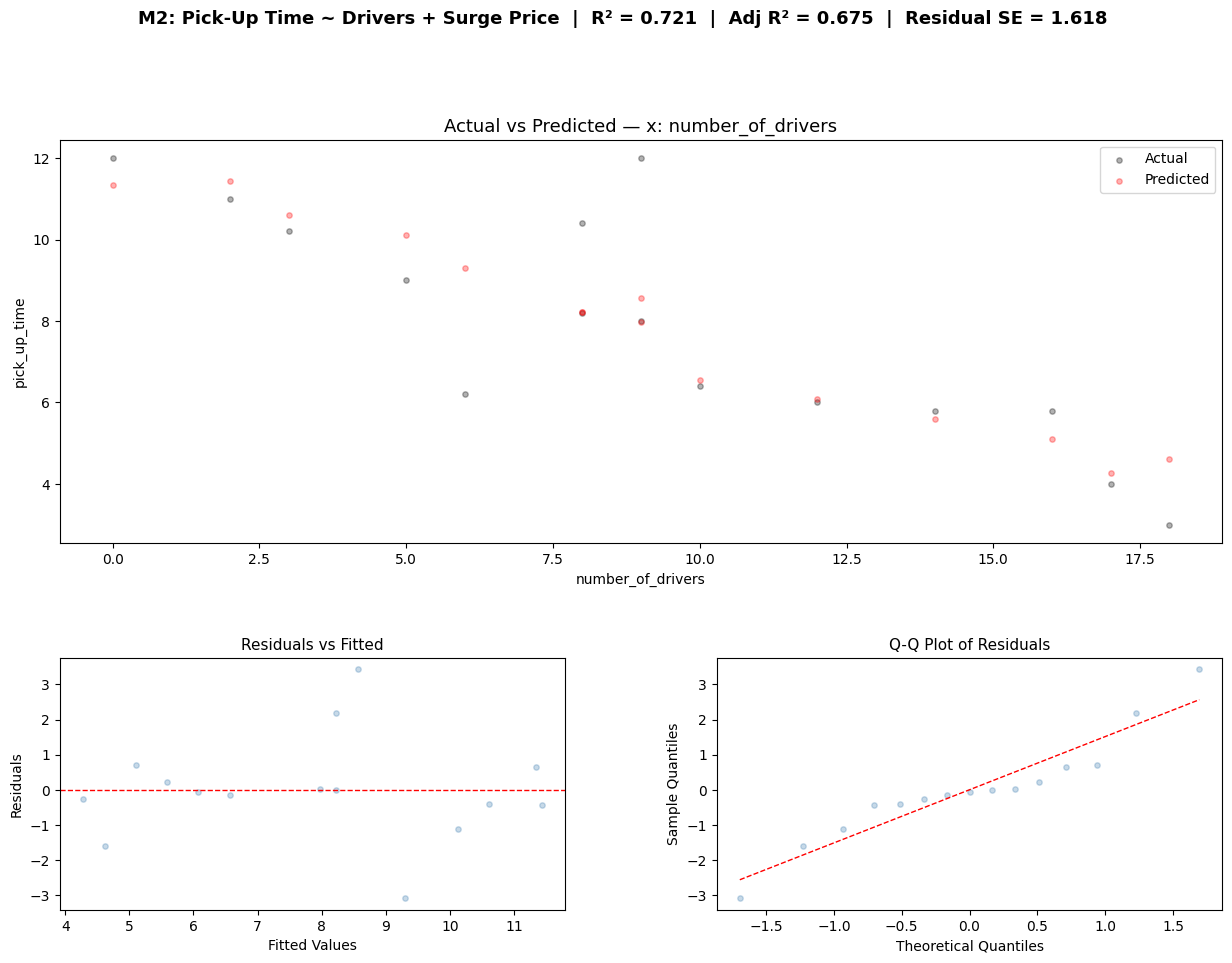

In [6]:
# Model 2: add surge_price to the driver-count model.
# WARNING: we already know from the heatmap that these two predictors
# are very strongly correlated — this may cause problems.
model2 = fit_and_plot(
    formula='pick_up_time ~ number_of_drivers + surge_price',
    data=uber_surge,
    model_name='M2: Pick-Up Time ~ Drivers + Surge Price',
    x_var='number_of_drivers'
)


### 8a. VIF Check

**VIF > 5-10** signals serious multicollinearity -- the coefficient estimates become unreliable because the model cannot separate the individual effects of correlated predictors.

### Section 8a – VIF Check for Multicollinearity

**VIF (Variance Inflation Factor)** measures how much a predictor's variance
is inflated because of its correlation with the other predictors.

Rule of thumb:
- VIF < 5 → no concern
- VIF 5–10 → moderate concern
- **VIF > 10 → serious multicollinearity**

Here both `number_of_drivers` and `surge_price` have VIF ≈ **25** — way above
the threshold. This means the coefficient estimates in Model 2 are unreliable;
the model can't distinguish the individual effect of each predictor.

**Fix:** drop one of the correlated predictors (we try both approaches in M3 and M4).


In [24]:
# Build a design matrix with only the numeric predictors + a constant column.
# We drop 'pick_up_time' (the outcome) and 'region' (categorical, handled differently).
X_vif = uber_surge.drop(columns=['pick_up_time', 'region']).assign(Intercept=1)

# Compute VIF for each predictor (excluding the intercept column itself).
# variance_inflation_factor() takes the full matrix and the column index to evaluate.
vif_data = pd.DataFrame({
    'feature': X_vif.columns.drop('Intercept'),
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1] - 1)]  # iterate over predictor columns only
}).round(2)

display(vif_data)  # VIF > 10 (or 5) signals multicollinearity


,feature,VIF
0,number_of_drivers,25.1
1,surge_price,25.1


### Finding

`number_of_drivers` and `surge_price` are near-perfectly negatively correlated (r ~ -0.98). This makes economic sense: surge pricing kicks in precisely when driver supply is low. Including both creates severe multicollinearity -- we must drop one.

## 9. Model 3 — Pick-Up Time ~ Surge Price Only

Drop `number_of_drivers` to resolve the multicollinearity issue.

## Section 9 – Model 3: Pick-Up Time ~ Surge Price Only

To fix the multicollinearity in Model 2, we **drop** `number_of_drivers` and
keep only `surge_price`.

Interpretation:
- **Intercept ≈ −2.13** — predicted wait when surge = 0 (not meaningful in practice, but mathematically it's where the line crosses y=0).
- **Coefficient ≈ +5.88** — each unit increase in the surge multiplier adds ~5.9 minutes of wait.
- **R² ≈ 0.619** — slightly *worse* than Model 1 (0.697). Surge price is a useful predictor, but driver count is marginally better.



  M3: Pick-Up Time ~ Surge Price
  R²: 0.6191    Adj R²: 0.5898    Residual SE: 1.8184
  Observations: 15    df residual: 13
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               -2.1314     2.2251   -0.958   0.3556 
  surge_price              5.8812     1.2794    4.597   0.0005 ***



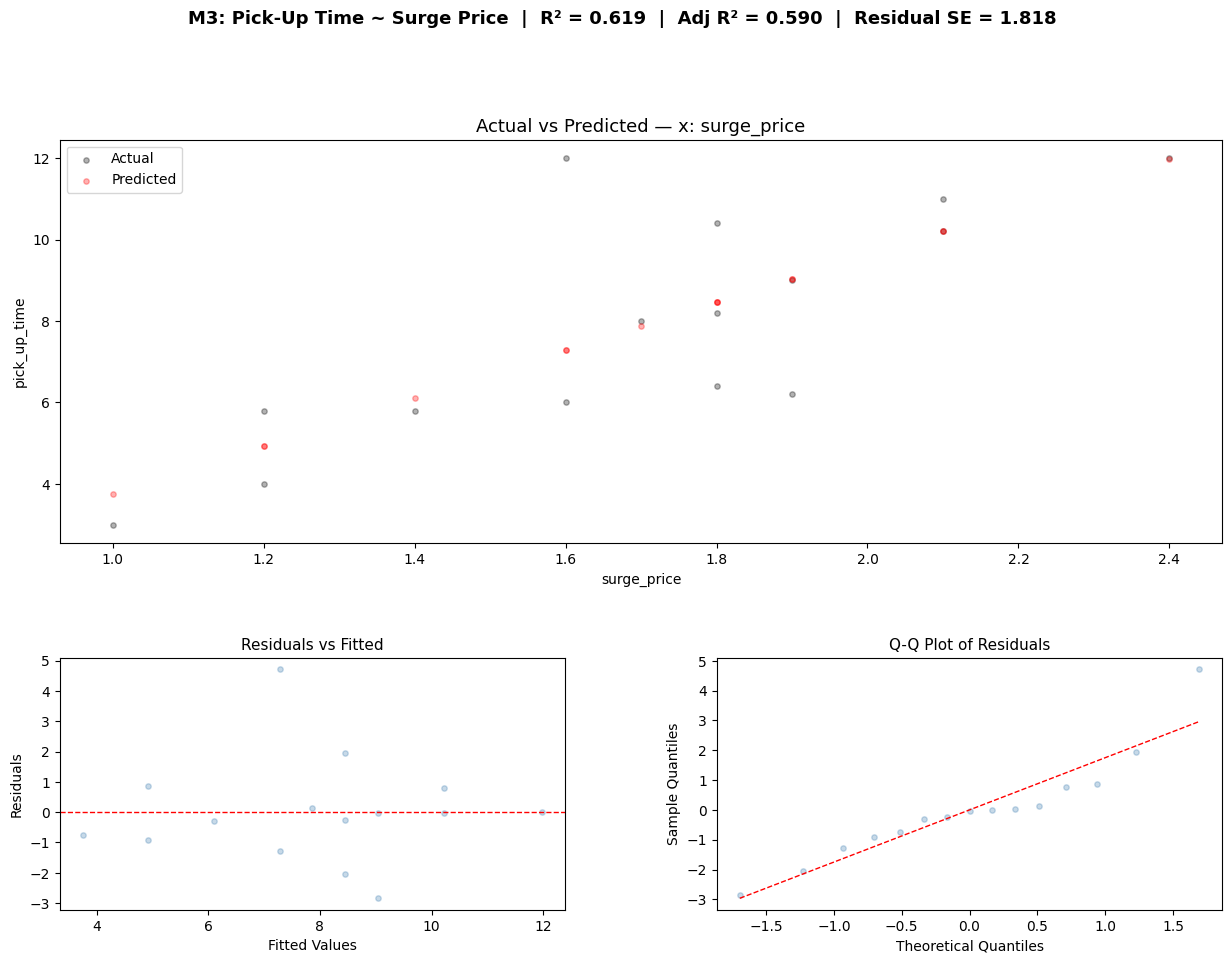

In [7]:
# Model 3: after discovering multicollinearity in M2, try surge_price alone.
# We dropped number_of_drivers to remove the collinear pair.
model3 = fit_and_plot(
    formula='pick_up_time ~ surge_price',
    data=uber_surge,
    model_name='M3: Pick-Up Time ~ Surge Price',
    x_var='surge_price'
)


## 10. Model 4 — Pick-Up Time ~ Drivers + Region

`region` is categorical -- statsmodels automatically creates dummy variables with one region held out as the reference level.

The `fit_and_plot` function detects `number_of_drivers` as continuous, so it shows the scatter plot. The region dummies shift the intercept but `x_var` stays as the continuous predictor for the top panel.

## Section 10 – Model 4: Pick-Up Time ~ Drivers + Region

Instead of surge price, let's try adding `region` (a **categorical** variable)
alongside driver count.

**How does statsmodels handle categorical variables?**
It automatically creates **dummy variables** — binary 0/1 columns, one per
category, with one category left out as the **reference level** (here: `'core'`).

So the model becomes:
```
pick_up_time = intercept
             + β₁ × number_of_drivers
             + β₂ × (1 if suburb, else 0)
```

Interpretation:
- **Intercept ≈ 11.01** — expected wait for a `core` pick-up with 0 drivers.
- **number_of_drivers ≈ −0.44** — each additional driver cuts ~0.44 min off the wait.
- **region[T.suburb] ≈ +1.71** — suburbs have ~1.7 minutes longer wait, holding driver count constant.
- **Adjusted R² ≈ 0.758** — best model so far! Region adds genuine explanatory power.
- **AIC = 55.2** — lowest (best) AIC of all models.



  M4: Pick-Up Time ~ Drivers + Region
  R²: 0.7927    Adj R²: 0.7582    Residual SE: 1.3962
  Observations: 15    df residual: 12
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               11.0097     0.7946   13.855   0.0000 ***
  region[T.suburb]         1.7058     0.7246    2.354   0.0364 *
  number_of_drivers       -0.4437     0.0682   -6.509   0.0000 ***



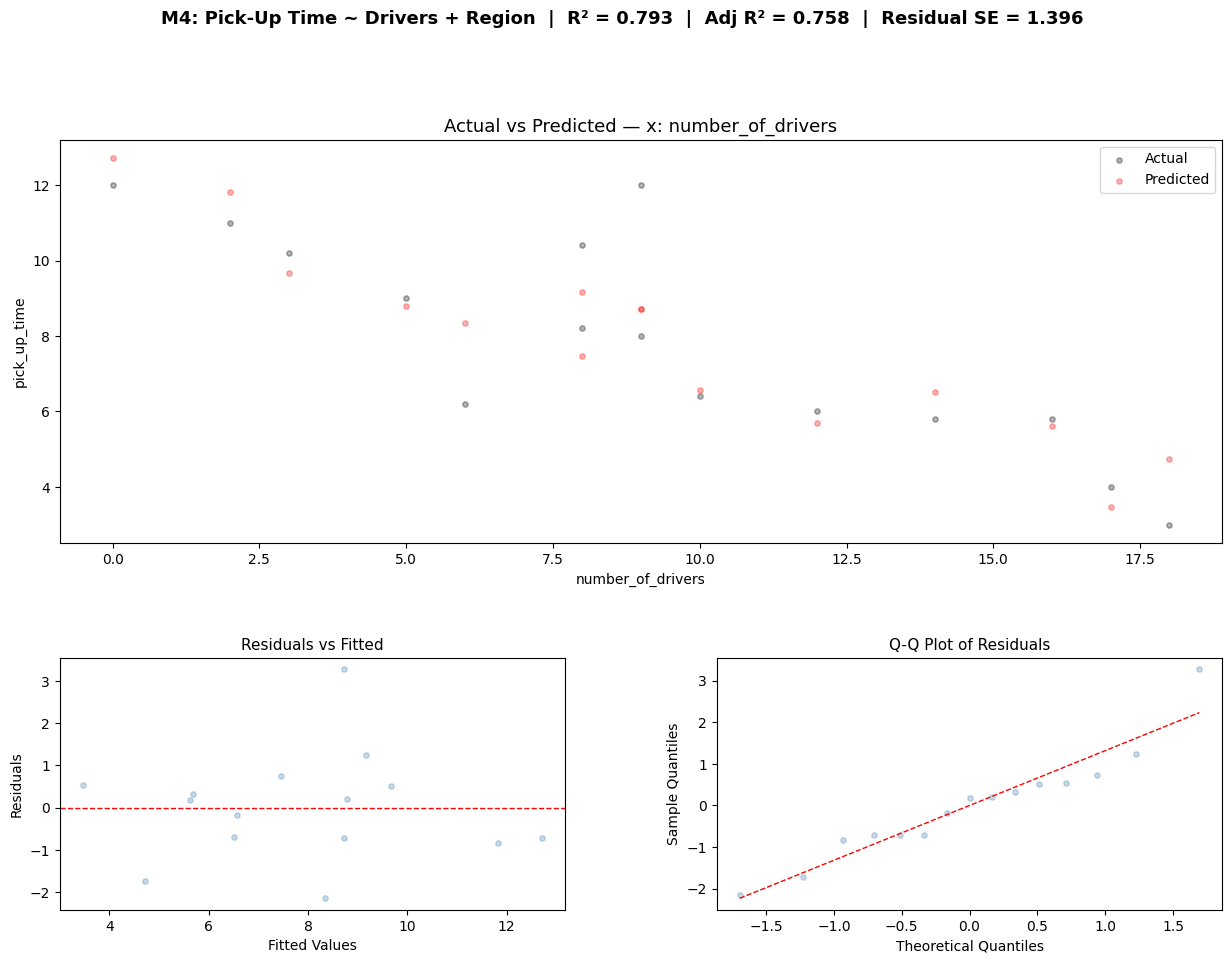

In [8]:
# Model 4: add the categorical variable 'region' to the driver-count model.
# statsmodels automatically creates dummy variables from string/category columns.
# The reference level (dropped dummy) is 'core'; 'suburb' gets a coefficient.
model4 = fit_and_plot(
    formula='pick_up_time ~ number_of_drivers + region',
    data=uber_surge,
    model_name='M4: Pick-Up Time ~ Drivers + Region',
    x_var='number_of_drivers'  # continuous variable goes on X-axis; region shifts the intercept
)


## 11. Model Comparison

Compare all models side by side. Look for higher Adj. R-squared, lower Residual SE, and lower AIC.

In [27]:
models = {
    'M1: ~drivers':          model1,
    'M2: ~drivers+surge':    model2,
    'M3: ~surge':            model3,
    'M4: ~drivers+region':   model4,
}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),
        'R2':          round(m.rsquared, 4),
        'Adj. R2':     round(m.rsquared_adj, 4),
        'Residual SE': round(m.scale ** 0.5, 3),
        'AIC':         round(m.aic, 1),
    }
    for name, m in models.items()
})
display(comparison)

,M1: ~drivers,M2: ~drivers+surge,M3: ~surge,M4: ~drivers+region
N,15.0000,15.0000,15.0000,15.0000
R2,0.6970,0.7215,0.6191,0.7927
Adj. R2,0.6737,0.6750,0.5898,0.7582
Residual SE,1.6220,1.6180,1.8180,1.3960
AIC,58.9000,59.7000,62.4000,55.2000


## Section 11 – Side-by-Side Model Comparison

Now we compare all models at once using two approaches:

**1. Custom DataFrame** — we pull specific metrics (N, R², Adjusted R², Residual SE, AIC)
into a clean table for easy scanning.

**2. `summary_col()`** — statsmodels' built-in function that prints a regression
table with all coefficients aligned by variable name. Stars indicate significance:
`*` p < 0.1, `**` p < 0.05, `***` p < 0.01.

### Winner: **Model 4** (drivers + region)
| Metric | M1 | M2 | M3 | **M4** |
|---|---|---|---|---|
| Adj. R² | 0.674 | 0.675 | 0.590 | **0.758** |
| Residual SE | 1.622 | 1.618 | 1.818 | **1.396** |
| AIC | 58.9 | 59.7 | 62.4 | **55.2** |

Model 4 explains the most variance, has the smallest prediction errors, and the
lowest AIC — all without the multicollinearity problem of Model 2.


In [28]:
# ── Approach 2: statsmodels summary_col() ────────────────────────────────
# summary_col() aligns coefficients by variable name so you can
# instantly see which predictors appear in which models.
# stars=True adds significance stars (* p<0.1, ** p<0.05, *** p<0.01).
summary = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    float_format='%0.3f',
    model_names=['M1', 'M2', 'M3', 'M4'],
    info_dict={'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"}  # custom row
)
print(summary)



                      M1       M2       M3        M4   
-------------------------------------------------------
Intercept         11.811*** 25.398*  -2.131   11.010***
                  (0.834)   (13.258) (2.225)  (0.795)  
number_of_drivers -0.432*** -0.829*           -0.444***
                  (0.079)   (0.395)           (0.068)  
surge_price                 -5.858   5.881***          
                            (5.705)  (1.279)           
region[T.suburb]                              1.706**  
                                              (0.725)  
R-squared         0.697     0.721    0.619    0.793    
R-squared Adj.    0.674     0.675    0.590    0.758    
Residual SE       1.622     1.618    1.818    1.396    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
